[nltk_data] Downloading package stopwords to
[nltk_data]     /home/d3f6f63e-2634-4630-b3e8-
[nltk_data]     bd2f955ed26a/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /home/d3f6f63e-2634-4630-b3e8-
[nltk_data]     bd2f955ed26a/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/d3f6f63e-2634-4630-b3e8-
[nltk_data]     bd2f955ed26a/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,category,text
0,Positive,I love this product! It works great and has ex...
1,Negative,Terrible experience. The product broke after o...
2,Positive,Fantastic! I would highly recommend this to ev...
3,Negative,Awful. It was a complete waste of money.
4,Positive,Amazing product! Very satisfied with my purchase.
5,Negative,Do not buy this. It is not worth the price.


,category,text,clean_text
0,Positive,I love this product! It works great and has ex...,love product work great excellent quality
1,Negative,Terrible experience. The product broke after o...,terrible experience product broke one use
2,Positive,Fantastic! I would highly recommend this to ev...,fantastic would highly recommend everyone
3,Negative,Awful. It was a complete waste of money.,awful complete waste money
4,Positive,Amazing product! Very satisfied with my purchase.,amazing product satisfied purchase
5,Negative,Do not buy this. It is not worth the price.,buy worth price


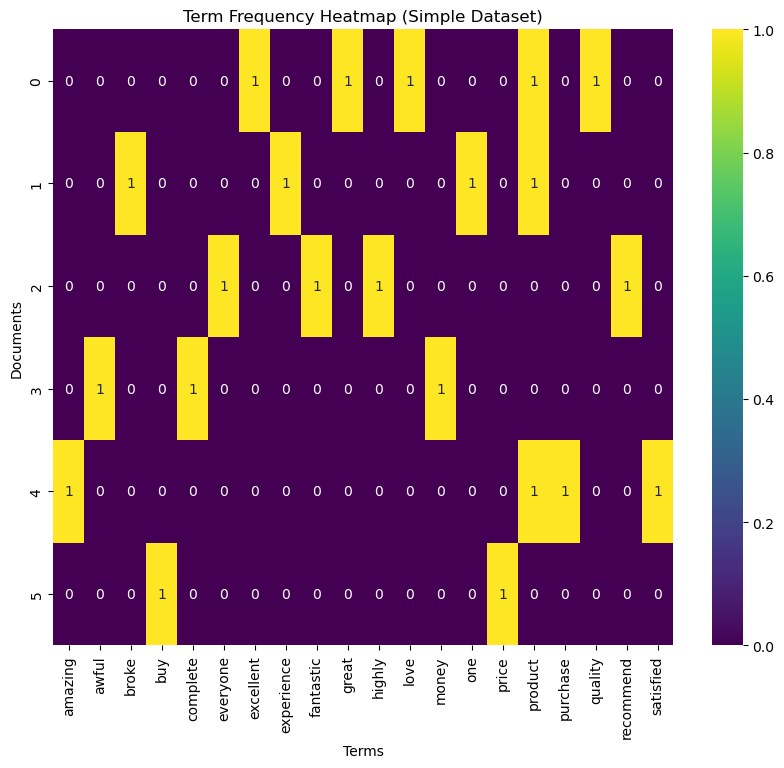

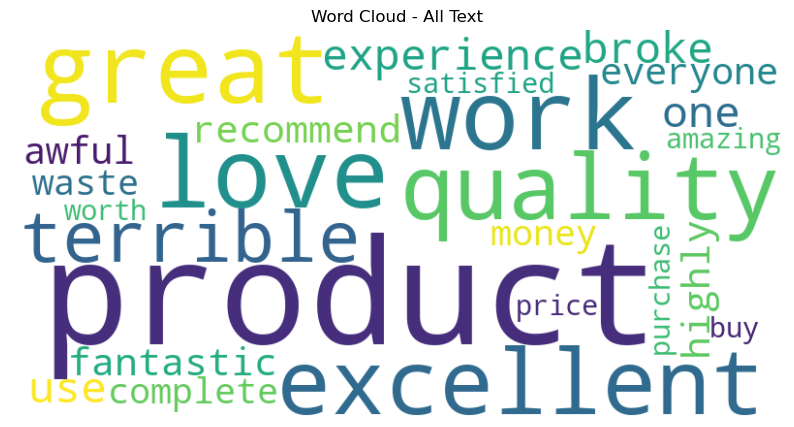

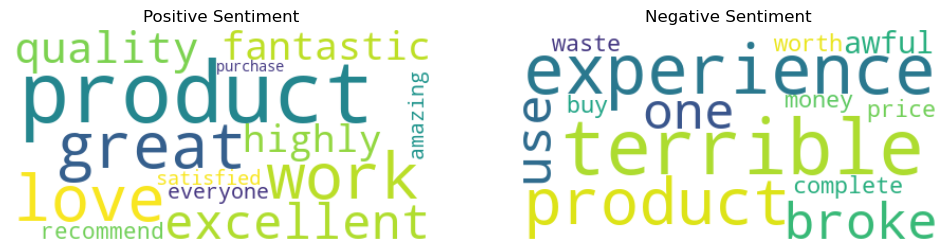

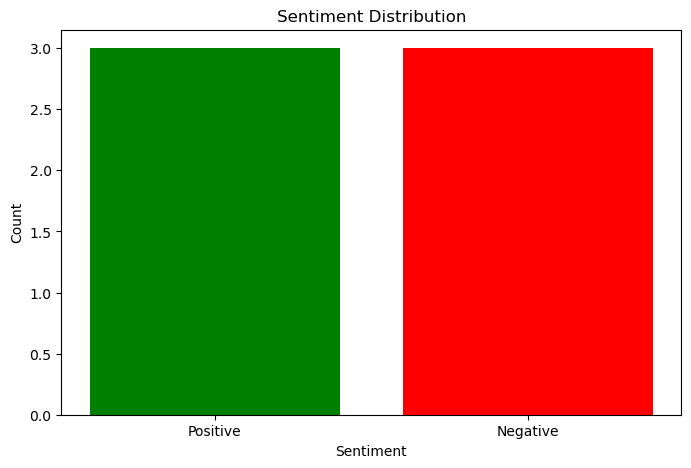

In [1]:
# =========================================
# PART A: SIMPLE DATASET
# =========================================

# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from IPython.display import display

# =========================
# 2. DOWNLOAD NLTK DATA
# =========================
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# =========================
# 3. PREPROCESS FUNCTION
# =========================
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    
    return ' '.join(tokens)

# =========================
# 4. LOAD DATASET
# =========================
df = pd.read_csv('simple_dataset.csv')
display(df)

# =========================
# 5. PREPROCESS TEXT
# =========================
df['clean_text'] = df['text'].apply(preprocess_text)
display(df)

# =========================
# 6. TERM FREQUENCY MATRIX
# =========================
vectorizer = CountVectorizer(max_features=20)
X = vectorizer.fit_transform(df['clean_text'])

terms = vectorizer.get_feature_names_out()
matrix = X.toarray()

# =========================
# 7. HEATMAP
# =========================
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, xticklabels=terms, cmap='viridis', annot=True)
plt.title("Term Frequency Heatmap (Simple Dataset)")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.show()

# =========================
# 8. WORD CLOUD (ALL TEXT)
# =========================
all_text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400, background_color='white')
wc.generate(all_text)

plt.figure(figsize=(10, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - All Text")
plt.show()

# =========================
# 9. WORD CLOUD BY SENTIMENT
# =========================
positive_text = " ".join(df[df['category'] == 'Positive']['clean_text'])
negative_text = " ".join(df[df['category'] == 'Negative']['clean_text'])

wc_pos = WordCloud(background_color='white').generate(positive_text)
wc_neg = WordCloud(background_color='white').generate(negative_text)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(wc_pos, interpolation='bilinear')
plt.title("Positive Sentiment")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wc_neg, interpolation='bilinear')
plt.title("Negative Sentiment")
plt.axis('off')

plt.show()

# =========================
# 10. SENTIMENT BAR CHART
# =========================
sentiment_counts = df['category'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()